# EBM model with decreasing albedo

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from ebm.params import *

%load_ext autoreload

## Global mean temp data

In [2]:
%autoreload
from esm.model import get_global_mean

global_mean_r25, global_mean_r1, global_mean_pi = get_global_mean()

/home/green/code/climate-modelling/climate-modelling-ebm/esm/model.py:7: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds_pi =xr.open_dataset('../data/tas_Amon_MPI-ESM1-2-LR_piControl_r1i1p1f1_g025_185001-284912.nc')
/home/green/code/climate-modelling/climate-modelling-ebm/esm/model.py:7: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds_pi =xr.open_dataset('../data/tas_Amon_MPI-ESM1-2-LR_piControl_r1i1p1f1_g025_185001-284912.nc')
/home/green/code/climate-modelling/climate-modelling-ebm/esm/model.py:7: SerializationWarning: Unable to decode time axis into full numpy.

## EBM Params

In [3]:
start_year = 1980
T_init = global_mean_r25.sel(time=str(start_year)).values[0]

params = {
    'T_init': T_init,
}

print(params['T_init'])

287.19958356396137


## EBM with linearly changing albedo

### Albedo time series

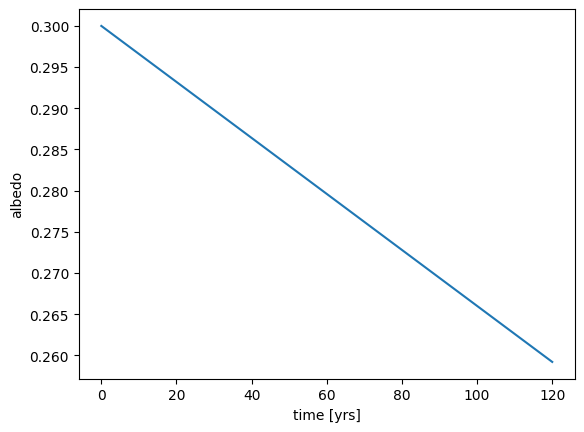

In [4]:
%autoreload
from ebm.model import albedo_of_time, model_alpha

dt = 86400.0            # time step in s
# t = np.arange(0, 120, 1)    # time in years
t = np.arange(0, 120*secyear, dt)    # time in s

# Initial planetary albedo
alpha_init = 0.3

# Albedo decreases by 0.34% = 0.0034 per decade
slope_decade = -0.0034 
slope_yr = slope_decade/10

# Compute albedo time series
alpha = albedo_of_time(t, alpha_init, slope=slope_yr/secyear)

t = t/secyear

plt.plot(t, alpha)
plt.ylabel('albedo')
plt.xlabel('time [yrs]')
plt.show()

### Global mean temp with decreasing albedo

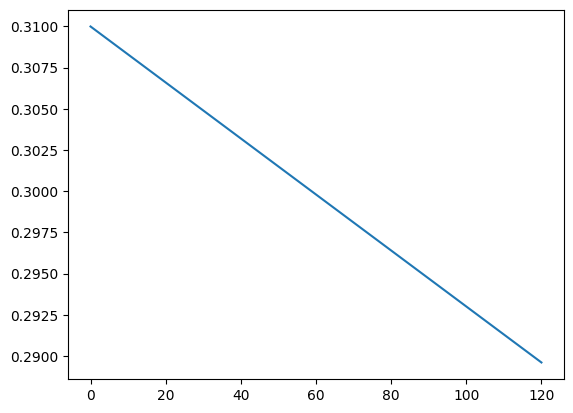

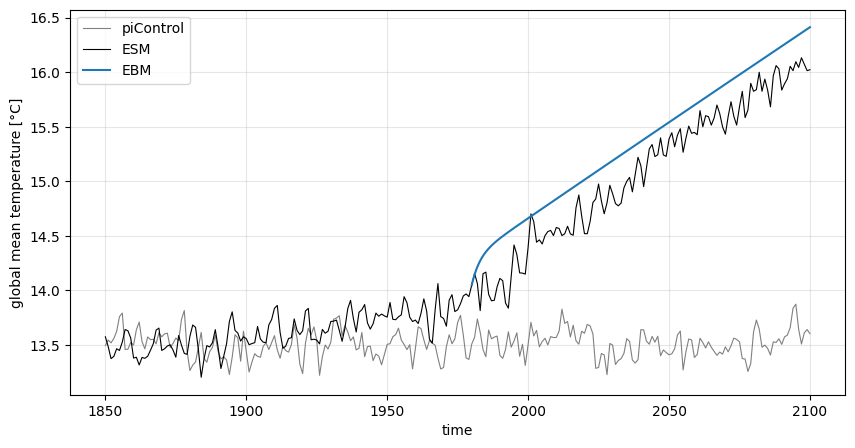

In [5]:
%autoreload
from ebm.model import model_alpha
from utils import plot_ebm_vs_esm

params['alpha_init'] = 0.31
params['alpha_slope'] = (slope_yr/2)/secyear    # slope in 1/s
# params['alpha_slope'] = 0    # slope in 1/s
params['maxtime'] = 120*secyear
params['dt'] = secday

# print(f'alpha = {alpha[10]} after {t[10]} years')

T, time, alpha = model_alpha(params)

plt.plot(time, alpha)

plot_ebm_vs_esm(
    time_ebm=time+1980,
    temp_ebm=T,
    time_esm=global_mean_r25.time.dt.year,
    temp_esm=global_mean_r25-273.15,
    temp_control=global_mean_pi-273.15
    )